# Pair Classifier — Confident Not-Match vs. Plausible (LightGBM, **non-match gate v1**)

**Entity resolution / non-match gating.** Over the **whole** pool of candidate record pairs,
predict **confident not-match** (`0`) vs **plausible = match or ambiguous** (`1`).
Positive = *"this pair is worth keeping"* (either a real match or a genuine hard case a human
should look at). This is the mirror image of the `_ambiguous_v3` notebook:

| | population | target 0 | target 1 |
|---|---|---|---|
| `_ambiguous_v3` | plausible only (match ∪ ambiguous) | confident match | ambiguous |
| **this notebook** | **whole dataset** | **confident not-match** | **match ∪ ambiguous (plausible)** |

**Everything else is held identical to v3** so metric changes are attributable to the target/population
change alone: the same 12 v3 features (§5), the same LightGBM config (§7), the same random
stratified 60/20/20 split and `RANDOM_STATE`.

**Role in the system.** This model **is the pipeline's non-match gate** (Stage 4.25,
`src/models/nonmatch_gate/`) — it replaced the FS matcher's `no_match` tier in that role,
and decides which of the deterministic rules' `non_matches` survive to the Stage-4.5
ambiguous classifier. It is *not* the served `ml_matcher` model: §11 saves it to its own
`models/nonmatch_gate/` store and promotes it through the **gate's** registry, never
touching `ml_matcher`'s `active.json`. See `docs/Nonmatch-Gate-Guide.md`.

> Training/evaluation notebook. §11 is the export + promote step the pipeline serves from.

## 1. Setup & configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import jellyfish

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)

pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

In [2]:
from pathlib import Path

def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError("could not locate empi-service/ (no ancestor has data/ + src/)")

SERVICE_ROOT = _find_service_root(Path.cwd())
DATA_DIR = SERVICE_ROOT / 'data'

GOLD_LABELS_PATH = DATA_DIR / 'gold_labels' / 'final_gold_labels_v1_2026_07_05.csv'
CLEANED_PATH = DATA_DIR / 'processed' / 'MDM_Population_cleaned_v6_2026_06_25.parquet'

print('service root :', SERVICE_ROOT)
print('gold labels  :', GOLD_LABELS_PATH, '-> exists:', GOLD_LABELS_PATH.exists())
print('cleaned data :', CLEANED_PATH, '-> exists:', CLEANED_PATH.exists())

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
gold labels  : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\gold_labels\final_gold_labels_v1_2026_07_05.csv -> exists: True
cleaned data : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\data\processed\MDM_Population_cleaned_v6_2026_06_25.parquet -> exists: True


## 2. Data ingestion
Identical to v3. `dtype=str` on PATIDs preserves the leading-zeros invariant.

In [3]:
gold = pd.read_csv(GOLD_LABELS_PATH, dtype={'PATID_A': str, 'PATID_B': str})


def _to_bool(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    return s.astype(str).str.strip().str.lower().map(
        {'true': True, '1': True, '1.0': True, 'false': False, '0': False, '0.0': False})


gold['final_gold_label'] = _to_bool(gold['final_gold_label']).fillna(False).astype(bool)
gold['ambiguous_pair'] = _to_bool(gold['ambiguous_pair']).fillna(False).astype(bool)

print('gold labels shape :', gold.shape)
print('\nfinal_gold_label x ambiguous_pair (counts):')
print(pd.crosstab(gold['final_gold_label'], gold['ambiguous_pair']))

gold labels shape : (204805, 4)

final_gold_label x ambiguous_pair (counts):
ambiguous_pair     False  True 
final_gold_label               
False             142195     73
True               34560  27977


In [4]:
ATTRIBUTE_COLS = [
    'FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
    'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base',
    'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set',
]
cleaned = pd.read_parquet(CLEANED_PATH)
keep = ['PATID'] + [c for c in ATTRIBUTE_COLS if c in cleaned.columns]
cleaned = cleaned[keep].copy()
cleaned['PATID'] = cleaned['PATID'].astype(str)
cleaned = cleaned.drop_duplicates(subset='PATID', keep='first').set_index('PATID')
print('cleaned records shape:', cleaned.shape)
print('columns available    :', list(cleaned.columns))

cleaned records shape: (163364, 11)
columns available    : ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean', 'SSN_clean', 'last_4_SSN', 'Email_clean', 'ZipCD_clean_base', 'AddressLine1_clean', 'SexAtBirthDSC_clean', 'Phones_set']


In [5]:
a = cleaned.add_suffix('_A').reindex(gold['PATID_A'].values).reset_index(drop=True)
b = cleaned.add_suffix('_B').reindex(gold['PATID_B'].values).reset_index(drop=True)
pairs = pd.concat([gold.reset_index(drop=True), a, b], axis=1)

n_unmatched = (~gold['PATID_A'].isin(cleaned.index) | ~gold['PATID_B'].isin(cleaned.index)).sum()
print(f'pairs with a PATID not found in cleaned data: {n_unmatched} / {len(pairs)}')
print('joined pairs shape:', pairs.shape)

pairs with a PATID not found in cleaned data: 0 / 204805
joined pairs shape: (204805, 26)


## 3. Target definition (no population filter)
**No filtering** — the whole candidate pool is used. Target: `1` = **plausible** (`final_gold_label`
OR `ambiguous_pair`; i.e. match ∪ ambiguous), `0` = **confident not-match** (neither).

This is exactly the complement of v3's `keep_mask`: the pairs v3 *dropped* as confident non-matches
are the negative class here, and the pairs v3 *kept* are the positive class.

In [6]:
pairs['target_plausible'] = (pairs['final_gold_label'] | pairs['ambiguous_pair']).astype(int)

print('target distribution (0=confident not-match, 1=plausible [match ∪ ambiguous]):')
print(pairs['target_plausible'].value_counts())
print(f"\npositive (plausible) rate: {pairs['target_plausible'].mean():.3f}")
print('\nbreakdown of the positive class:')
print(f"  confident match (final_gold_label & ~ambiguous): {int((pairs['final_gold_label'] & ~pairs['ambiguous_pair']).sum())}")
print(f"  ambiguous       (ambiguous_pair)               : {int(pairs['ambiguous_pair'].sum())}")

target distribution (0=confident not-match, 1=plausible [match ∪ ambiguous]):
target_plausible
0    142195
1     62610
Name: count, dtype: int64

positive (plausible) rate: 0.306

breakdown of the positive class:
  confident match (final_gold_label & ~ambiguous): 34560
  ambiguous       (ambiguous_pair)               : 28050


## 4. Field selection
Same 8-field roster as v3. Drives both the **internal** `cmp_all` comparison (used for the
aggregate-free subgroup rule + ablation) and the v3 similarity features.

In [7]:
AVAILABLE_FIELDS = {
    'first_name':  'FirstNM_clean',
    'last_name':   'LastNM_clean',
    'middle_name': 'MiddleNM_clean',
    'birth_date':  'BirthDT_clean',
    'email':       'Email_clean',
    'ssn':         'SSN_clean',
    'address1':    'AddressLine1_clean',
    'phones':      'Phones_set',
}
SET_FIELDS = {'phones'}
SELECTED_FIELDS = ['first_name', 'last_name', 'middle_name', 'birth_date',
                   'email', 'ssn', 'address1', 'phones']
assert set(SELECTED_FIELDS) <= set(AVAILABLE_FIELDS)
print('fields:', SELECTED_FIELDS)

fields: ['first_name', 'last_name', 'middle_name', 'birth_date', 'email', 'ssn', 'address1', 'phones']


## 5. Feature engineering

Identical to v3. All features are continuous **except** `cmp_street_num`, `sound_first`,
`sound_last` (3-level categoricals). Missing on either side → `NaN`, handled natively by LightGBM.

| Feature | Type | Definition |
|---|---|---|
| `sim_jw_first` / `sim_jw_last` / `sim_jw_middle` | num | Jaro-Winkler on the name |
| `sound_first` / `sound_last` | cat | Metaphone code match (sound-alike) |
| `sim_lev_email` | num | normalized Levenshtein on email |
| `sim_lev_address1` | num | normalized Levenshtein on address line 1 |
| `addr_token_jaccard` | num | token overlap (Jaccard) of the address |
| `cmp_street_num` | cat | first numeric token of the address, matched exactly |
| `ssn_digit_frac` | num | fraction of position-wise matching SSN digits |
| `sim_dob` | num | normalized Levenshtein on the `YYYYMMDD` birth-date string |
| `sim_phones` | num | best (max) Jaro-Winkler across all cross pairs of the two phone sets |

In [8]:
import ast, re

MISSING, SAME, DIFFERENT = 'missing', 'same', 'different'
COMPARE_LEVELS = [MISSING, SAME, DIFFERENT]
_num_re = re.compile(r'\d+')
_NA_TOKENS = {'nan', 'none', '<na>', 'nat', 'null'}


def _norm(x):
    """Value -> lowercased stripped str, or None for any missing kind
    (None / np.nan / pd.NA / NaT). pd.NA is NOT an np.isscalar, so we test via pd.isna()."""
    if isinstance(x, str):
        s = x.strip().lower()
        return s if s and s not in _NA_TOKENS else None
    if x is None:
        return None
    try:
        if pd.isna(x):
            return None
    except (TypeError, ValueError):
        pass
    s = str(x).strip().lower()
    return s if s and s not in _NA_TOKENS else None


def _norm_series(s: pd.Series) -> pd.Series:
    return s.astype(object).map(_norm)


def _parse_set(value) -> set:
    """Set-valued cell (phones) -> set of strings. Handles native array/list and legacy string."""
    if isinstance(value, (set, frozenset, list, tuple, np.ndarray)):
        return {str(p).strip() for p in value if str(p).strip()}
    if pd.isna(value) or not isinstance(value, str):
        return set()
    v = value.strip()
    if v in ('', 'nan', 'None', 'set()', '{}', '[]'):
        return set()
    try:
        parsed = ast.literal_eval(v)
        if isinstance(parsed, (set, list, tuple)):
            return {str(p).strip() for p in parsed if str(p).strip()}
    except (ValueError, SyntaxError, TypeError):
        pass
    cleaned = v.strip('{}[]').replace("'", '').replace('"', '')
    return {p.strip() for p in cleaned.split(',') if p.strip()}


def _jw(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    return jellyfish.jaro_winkler_similarity(x, y)


def _lev_sim(x, y):
    if not (isinstance(x, str) and isinstance(y, str)):
        return np.nan
    m = max(len(x), len(y))
    return 1.0 - jellyfish.levenshtein_distance(x, y) / m if m else np.nan

### 5.1 Internal per-field comparison (`cmp_all`)
Computed for all eight fields but **not** used as model features (per v3, the aggregates are
dropped). It feeds the section-9 subgroup rule and the ablation baseline only.

In [9]:
def compare_field(df: pd.DataFrame, name: str, col: str) -> pd.Categorical:
    if name in SET_FIELDS:
        a = df[f'{col}_A'].apply(_parse_set)
        b = df[f'{col}_B'].apply(_parse_set)
        missing = (a.map(len) == 0) | (b.map(len) == 0)
        same = pd.Series([bool(x & y) for x, y in zip(a, b)], index=df.index) & ~missing
    else:
        a = _norm_series(df[f'{col}_A'])
        b = _norm_series(df[f'{col}_B'])
        missing = a.isna() | b.isna()
        same = (a == b) & ~missing
    out = np.where(missing, MISSING, np.where(same, SAME, DIFFERENT))
    return pd.Categorical(out, categories=COMPARE_LEVELS)


cmp_all = pd.DataFrame(index=pairs.index)
for name in SELECTED_FIELDS:
    cmp_all[f'cmp_{name}'] = compare_field(pairs, name, AVAILABLE_FIELDS[name])
print('internal cmp_all columns:', list(cmp_all.columns))

internal cmp_all columns: ['cmp_first_name', 'cmp_last_name', 'cmp_middle_name', 'cmp_birth_date', 'cmp_email', 'cmp_ssn', 'cmp_address1', 'cmp_phones']


### 5.2 Model features

In [10]:
feat = pd.DataFrame(index=pairs.index)
cat_features, num_features = [], []


def sim_column(col, fn):
    a = _norm_series(pairs[f'{col}_A'])
    b = _norm_series(pairs[f'{col}_B'])
    return pd.Series([fn(x, y) for x, y in zip(a, b)], index=pairs.index, dtype='float')


# --- Names: Jaro-Winkler ---
for name in ['first_name', 'last_name', 'middle_name']:
    feat[f'sim_jw_{name.split("_")[0]}'] = sim_column(AVAILABLE_FIELDS[name], _jw)
num_features += ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle']

# --- Email / address: normalized Levenshtein only ---
feat['sim_lev_email'] = sim_column('Email_clean', _lev_sim)
feat['sim_lev_address1'] = sim_column('AddressLine1_clean', _lev_sim)
num_features += ['sim_lev_email', 'sim_lev_address1']

In [11]:
# --- Names: phonetic (Metaphone) sound-alike match ---
def _metaphone(x):
    s = _norm(x)
    if not s:
        return None
    return jellyfish.metaphone(s) or None


def sound_cmp(col):
    a = pairs[f'{col}_A'].map(_metaphone)
    b = pairs[f'{col}_B'].map(_metaphone)
    missing = a.isna() | b.isna()
    same = (a == b) & ~missing
    return pd.Categorical(np.where(missing, MISSING, np.where(same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)


feat['sound_first'] = sound_cmp('FirstNM_clean')
feat['sound_last'] = sound_cmp('LastNM_clean')
cat_features += ['sound_first', 'sound_last']

In [12]:
# --- Address: street number (first numeric token), matched exactly; + token Jaccard ---
def _street_num(x):
    s = _norm(x)
    if not s:
        return None
    m = _num_re.search(s)
    return m.group() if m else None


sn_a = pairs['AddressLine1_clean_A'].map(_street_num)
sn_b = pairs['AddressLine1_clean_B'].map(_street_num)
sn_missing = sn_a.isna() | sn_b.isna()
sn_same = (sn_a == sn_b) & ~sn_missing
feat['cmp_street_num'] = pd.Categorical(
    np.where(sn_missing, MISSING, np.where(sn_same, SAME, DIFFERENT)), categories=COMPARE_LEVELS)
cat_features.append('cmp_street_num')


def _tok_jaccard(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    sx, sy = set(x.split()), set(y.split())
    return len(sx & sy) / len(sx | sy) if sx and sy else np.nan


feat['addr_token_jaccard'] = pd.Series(
    [_tok_jaccard(x, y) for x, y in zip(pairs['AddressLine1_clean_A'], pairs['AddressLine1_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('addr_token_jaccard')

In [13]:
# --- SSN: fraction of position-wise matching digits (typo-tolerant). ---
def _ssn_frac(x, y):
    x, y = _norm(x), _norm(y)
    if not x or not y:
        return np.nan
    n = min(len(x), len(y))
    if n == 0:
        return np.nan
    return sum(1 for i in range(n) if x[i] == y[i]) / max(len(x), len(y))


feat['ssn_digit_frac'] = pd.Series(
    [_ssn_frac(x, y) for x, y in zip(pairs['SSN_clean_A'], pairs['SSN_clean_B'])],
    index=pairs.index, dtype='float')
num_features.append('ssn_digit_frac')

In [14]:
# --- DOB: typo-tolerant similarity on the YYYYMMDD digit string (normalized Levenshtein). ---
dob_a = pd.to_datetime(pairs['BirthDT_clean_A'], errors='coerce')
dob_b = pd.to_datetime(pairs['BirthDT_clean_B'], errors='coerce')
sa = dob_a.dt.strftime('%Y%m%d')   # NaT -> NaN
sb = dob_b.dt.strftime('%Y%m%d')
feat['sim_dob'] = pd.Series([_lev_sim(x, y) for x, y in zip(sa, sb)], index=pairs.index, dtype='float')
num_features.append('sim_dob')

In [15]:
# --- Phones: best (max) Jaro-Winkler across all cross pairs of the two phone sets. ---
#     = smallest JW distance. Exact shared number -> 1.0; a one-digit typo still scores high.
def _phones_best_jw(av, bv):
    A, B = _parse_set(av), _parse_set(bv)
    if not A or not B:
        return np.nan
    return max(jellyfish.jaro_winkler_similarity(x, y) for x in A for y in B)


feat['sim_phones'] = pd.Series(
    [_phones_best_jw(av, bv) for av, bv in zip(pairs['Phones_set_A'], pairs['Phones_set_B'])],
    index=pairs.index, dtype='float')
num_features.append('sim_phones')

In [16]:
# Finalize: categorical dtype for tree-native categoricals; assemble feature list.
for c in cat_features:
    feat[c] = feat[c].astype('category')

FEATURE_COLS = cat_features + num_features
print(f'{len(cat_features)} categorical + {len(num_features)} numeric = {len(FEATURE_COLS)} features')
print('\ncategorical:', cat_features)
print('numeric    :', num_features)
feat[FEATURE_COLS].head()

3 categorical + 9 numeric = 12 features

categorical: ['sound_first', 'sound_last', 'cmp_street_num']
numeric    : ['sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,same,same,same,1.000000,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
1,same,same,same,1.000000,1.0,NaN,0.464286,1.000000,1.000000,NaN,1.0,1.000000
2,same,same,same,0.971429,1.0,NaN,NaN,1.000000,1.000000,NaN,1.0,1.000000
3,same,same,different,1.000000,1.0,NaN,1.000000,0.285714,0.166667,1.0,1.0,1.000000
4,same,same,different,1.000000,1.0,NaN,NaN,0.476190,0.333333,NaN,1.0,0.622222


### 5.3 Feature ↔ target signal check

In [17]:
y_full = pairs['target_plausible']
rows = []
for c in num_features:
    rows.append({'feature': c,
                 'mean_not_match': feat.loc[y_full == 0, c].mean(),
                 'mean_plausible': feat.loc[y_full == 1, c].mean(),
                 'pct_missing': feat[c].isna().mean()})
print('Numeric features — mean by class (0=confident not-match, 1=plausible):')
display(pd.DataFrame(rows).round(3))

for c in cat_features:
    ct = pairs.groupby(feat[c].astype('object'), observed=True)['target_plausible'].mean().round(3)
    print(f'{c:16s} P(plausible|outcome): ' + '  '.join(f'{k}={v}' for k, v in ct.items()))

Numeric features — mean by class (0=confident not-match, 1=plausible):


,feature,mean_not_match,mean_plausible,pct_missing
0,sim_jw_first,0.445,0.993,0.000
1,sim_jw_last,0.477,0.967,0.000
2,sim_jw_middle,0.143,0.907,0.972
3,sim_lev_email,0.613,0.830,0.948
4,sim_lev_address1,0.690,0.514,0.041
5,addr_token_jaccard,0.600,0.369,0.041
6,ssn_digit_frac,0.199,0.982,0.770
7,sim_dob,0.468,1.000,0.000
8,sim_phones,0.962,0.806,0.042


sound_first      P(plausible|outcome): different=0.011  missing=1.0  same=0.93
sound_last       P(plausible|outcome): different=0.065  missing=1.0  same=0.769
cmp_street_num   P(plausible|outcome): different=0.416  missing=0.587  same=0.197


## 6. Train / validation / test split — the SHARED holdout

The test fold is **not drawn here**. `src.evaluation.holdout.holdout_mask` defines
it, and the same function is called by the other training notebook and by both
evaluation CLIs — so there is exactly one definition of the split and the two
served models are held out on exactly the same pairs.

**How it is defined.** A pair is held out iff
`sha256(PATID_A|PATID_B|salt)`, read as a fraction in [0, 1), is below
`HOLDOUT_FRACTION` (0.20). Membership therefore depends only on the pair's own
identity, which buys three things:

* **order-invariance** — `train_test_split` is positional, so re-saving the gold
  CSV in a different row order would silently change which pairs are held out and
  invalidate every already-trained model, with nothing raised;
* **stability under growth** — appending new gold labels re-partitions nothing;
* **stratification for free** — the hash is independent of the label, so it takes
  ~20% of every class without being told the classes exist (measured: non-match
  19.98%, ambiguous 20.18%, match 19.71%).

**Why not a per-notebook split, as before?** Each notebook used to call
`train_test_split` itself and `holdout.py` reconstructed those splits separately.
The folds were *different* 20%s, so "pairs neither model saw" was their
intersection — ~8k of 204,805 — and the reconstruction drifted silently when a
notebook changed its stratification target, quietly contaminating every
"leakage-safe" number. One shared function makes the safe set the full ~41k
(~5x the positive labels) and leaves nothing to drift.

Train/val is still split here (75/25 of the remaining 80% → 60/20 overall);
only the *test* fold has to be shared.

In [18]:
import sys
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
from src.evaluation.holdout import holdout_mask, holdout_spec   # noqa: E402

X = feat[FEATURE_COLS]
y = pairs['target_plausible'].astype(int)

# The shared holdout — same function the other notebook and the eval CLIs call.
HOLDOUT_SPEC = holdout_spec()          # recorded in the model meta (section 11)
is_test = holdout_mask(pairs)

idx_test = np.flatnonzero(is_test)
idx_trainval = np.flatnonzero(~is_test)
assert len(idx_test) > 0, 'empty holdout — check PATID formatting in the gold file'

idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y.iloc[idx_trainval])

X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
X_val,   y_val   = X.iloc[idx_val],   y.iloc[idx_val]
X_test,  y_test  = X.iloc[idx_test],  y.iloc[idx_test]

print(f'holdout spec: {HOLDOUT_SPEC}')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{name:5s}: n={len(yy):6d}  pos={yy.sum():6d}  pos_rate={yy.mean():.3f}')

holdout spec: {'method': 'sha256_bucket', 'salt': 'empi-holdout-v1', 'fraction': 0.2, 'version': 1}
train: n=122967  pos= 37633  pos_rate=0.306
val  : n= 40989  pos= 12544  pos_rate=0.306
test : n= 40849  pos= 12433  pos_rate=0.304


## 7. Model training
Same LightGBM configuration as v3 — only the target/population differs. `class_weight='balanced'`
handles the ~2.3:1 negative:positive imbalance of the full pool.

In [19]:
params = dict(
    objective='binary', n_estimators=1000, learning_rate=0.05, num_leaves=15,
    min_child_samples=20, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

model = lgb.LGBMClassifier(**params)
model.fit(
    X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='auc',
    categorical_feature=cat_features,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)],
)
print('best iteration:', model.best_iteration_)
print('best val AUC  :', round(model.best_score_['valid_0']['auc'], 4))

best iteration: 142
best val AUC  : 0.9998


## 8. Model evaluation (full held-out test set)
Positive class = **plausible**. As a **non-match gate** the costly error is a *false negative* —
discarding a true match/ambiguous pair as "confident not-match" (unrecoverable downstream). So the
threshold favors **recall on the positive (plausible) class**: keep the default low `0.3`, and read
the PR curve in §8.2 to pick a gate operating point from the tolerable false-negative rate.

In [20]:
DECISION_THRESHOLD = 0.3
proba_test = model.predict_proba(X_test)[:, 1]   # P(plausible)
pred_test = (proba_test >= DECISION_THRESHOLD).astype(int)

print('Classification report (full test):\n')
print(classification_report(y_test, pred_test, target_names=['confident not-match (0)', 'plausible (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_test, proba_test):.4f}')
print(f'PR  AUC : {average_precision_score(y_test, proba_test):.4f}')

Classification report (full test):

                         precision    recall  f1-score   support

confident not-match (0)      1.000     0.983     0.991     28416
          plausible (1)      0.962     0.999     0.980     12433

               accuracy                          0.988     40849
              macro avg      0.981     0.991     0.986     40849
           weighted avg      0.988     0.988     0.988     40849

ROC AUC : 0.9997
PR  AUC : 0.9993


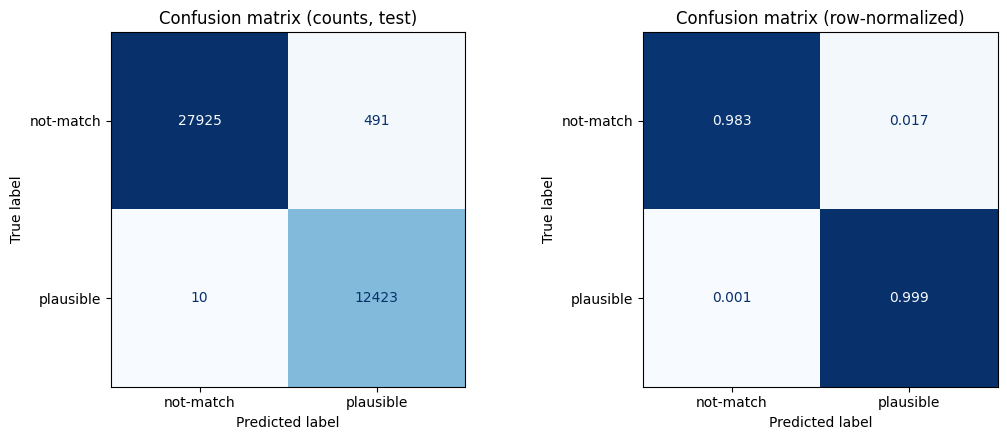

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['not-match', 'plausible']
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test), display_labels=labels).plot(ax=ax[0], colorbar=False, cmap='Blues')
ax[0].set_title('Confusion matrix (counts, test)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test, normalize='true'), display_labels=labels).plot(ax=ax[1], colorbar=False, cmap='Blues', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

### 8.2 ROC / PR curves

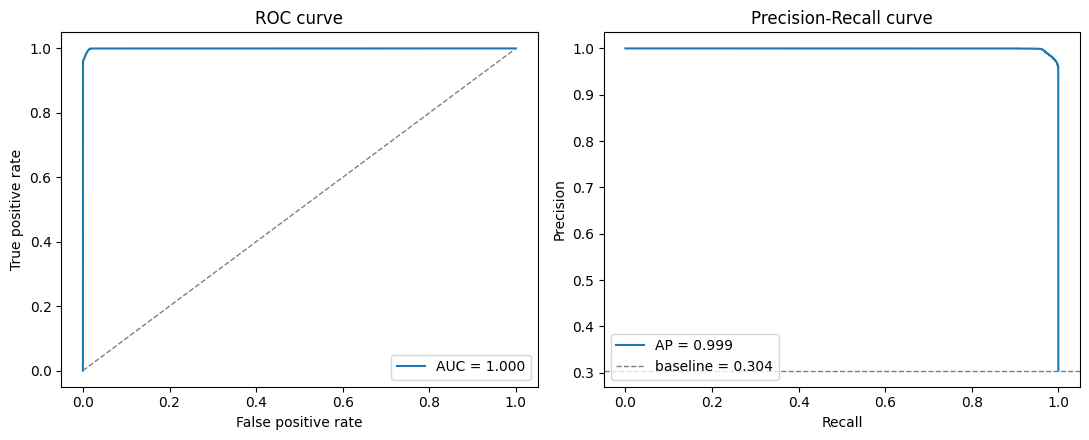

In [22]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, proba_test):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', linewidth=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve'); ax[0].legend(loc='lower right')
ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_test, proba_test):.3f}')
ax[1].axhline(y_test.mean(), ls='--', color='grey', linewidth=1, label=f'baseline = {y_test.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall curve'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

### 8.3 Gate operating points
For a non-match gate, the metric that matters is: at a given threshold, **what fraction of true
plausible pairs do we wrongly drop** (positive-class miss rate), and **how much of the pool do we
discard**. This table scans thresholds so you can size the gate against a tolerable miss rate.

In [23]:
rows = []
P = int((y_test == 1).sum())
N = int((y_test == 0).sum())
for thr in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    keep = proba_test >= thr                     # predicted plausible -> passes the gate
    tp = int(((y_test == 1) & keep).sum())
    fn = int(((y_test == 1) & ~keep).sum())      # true plausible wrongly dropped
    fp = int(((y_test == 0) & keep).sum())       # true not-match wrongly kept
    tn = int(((y_test == 0) & ~keep).sum())      # true not-match correctly dropped
    rows.append({
        'threshold': thr,
        'kept_frac': keep.mean(),
        'plausible_recall': tp / P,
        'plausible_miss_rate': fn / P,
        'not_match_dropped_frac': tn / N,
        'kept_precision': tp / (tp + fp) if (tp + fp) else float('nan'),
    })
pd.DataFrame(rows).round(4)

,threshold,kept_frac,plausible_recall,plausible_miss_rate,not_match_dropped_frac,kept_precision
0,0.1,0.3178,0.9998,0.0002,0.9806,0.9576
1,0.2,0.3167,0.9995,0.0005,0.9821,0.9607
2,0.3,0.3161,0.9992,0.0008,0.9827,0.9620
3,0.4,0.3155,0.9986,0.0014,0.9834,0.9633
4,0.5,0.3147,0.9979,0.0021,0.9843,0.9652
5,0.6,0.3128,0.9964,0.0036,0.9863,0.9695
6,0.7,0.3059,0.9858,0.0142,0.9916,0.9810


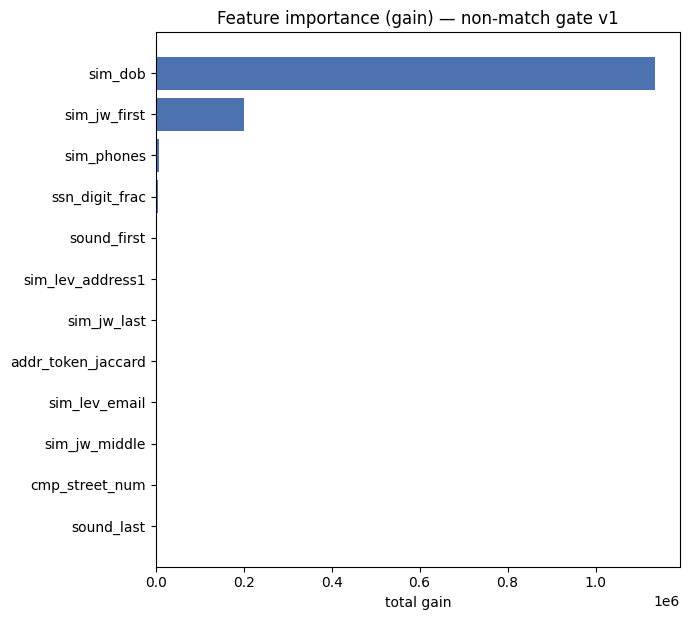

,feature,gain,split
10,sim_dob,1.135189e+06,249
3,sim_jw_first,1.998953e+05,432
11,sim_phones,8.510815e+03,254
9,ssn_digit_frac,4.590503e+03,280
0,sound_first,3.740106e+03,81
7,sim_lev_address1,2.813867e+03,226
4,sim_jw_last,2.203060e+03,138
8,addr_token_jaccard,2.017556e+03,116
6,sim_lev_email,8.225788e+02,93
5,sim_jw_middle,7.336704e+02,98


In [24]:
imp = pd.DataFrame({'feature': model.feature_name_,
                    'gain': model.booster_.feature_importance(importance_type='gain'),
                    'split': model.booster_.feature_importance(importance_type='split')}).sort_values('gain', ascending=False)
fig, ax = plt.subplots(figsize=(7, 0.4 * len(imp) + 1.5))
ax.barh(imp['feature'][::-1], imp['gain'][::-1], color='#4C72B0')
ax.set(title='Feature importance (gain) — non-match gate v1', xlabel='total gain')
plt.tight_layout(); plt.show()
imp

## 9. Deterministic-rule subgroup — dual evaluation

Same **label-independent feature rule** as v3 (no leakage): pairs that agree only on
first + last + DOB with everything else missing/disagreeing.

> `cmp_first_name == cmp_last_name == cmp_birth_date == same` **and** every other field `!= same`.

Here the question is different: on the **whole** pool, how *plausible* is this subgroup, and how much
of the gate's performance rides on these easy cases? We report model metrics **both** on the full
test set and on the **residual** (subgroup removed).

In [25]:
AGREE_COLS = ['cmp_first_name', 'cmp_last_name', 'cmp_birth_date']
OTHER_COLS = [c for c in cmp_all.columns if c not in AGREE_COLS]

def subgroup_mask(index_like):
    sub = cmp_all.loc[index_like]
    three_agree = (sub[AGREE_COLS] == SAME).all(axis=1)
    rest_not_same = (sub[OTHER_COLS] != SAME).all(axis=1)   # different OR missing
    return (three_agree & rest_not_same).values

# Whole population.
mask_all = subgroup_mask(pairs.index)
n_sub = int(mask_all.sum())
plaus_rate_sub = pairs.loc[mask_all, 'target_plausible'].mean() if n_sub else float('nan')
print(f'subgroup size (full population): {n_sub} / {len(pairs)}  ({n_sub/len(pairs):.1%})')
print(f'  plausible rate within subgroup: {plaus_rate_sub:.3f}   (overall: {pairs["target_plausible"].mean():.3f})')
print(f'  -> a deterministic "pass the gate" rule on this subgroup would be right {plaus_rate_sub:.1%} of the time')

subgroup size (full population): 24373 / 204805  (11.9%)
  plausible rate within subgroup: 0.999   (overall: 0.306)
  -> a deterministic "pass the gate" rule on this subgroup would be right 99.9% of the time


In [26]:
# Test-set split into subgroup vs residual.
test_index = pairs.index[idx_test]
mask_test_sub = subgroup_mask(test_index)
resid = ~mask_test_sub
print(f'test set: {mask_test_sub.sum()} subgroup, {resid.sum()} residual (of {len(y_test)})\n')


def report(mask, title):
    yy, pp, sc = y_test.values[mask], pred_test[mask], proba_test[mask]
    if len(yy) == 0 or len(np.unique(yy)) < 2:
        print(f'--- {title} (n={len(yy)}): too few / single-class, skipping AUC ---')
        if len(yy):
            print(f'    accuracy={ (yy==pp).mean():.3f}  plausible_rate={yy.mean():.3f}')
        return
    print(f'--- {title} (n={len(yy)}, plausible_rate={yy.mean():.3f}) ---')
    print(classification_report(yy, pp, target_names=['not-match', 'plausible'], digits=3, zero_division=0))
    print(f'    ROC AUC={roc_auc_score(yy, sc):.4f}   PR AUC={average_precision_score(yy, sc):.4f}\n')


report(np.ones(len(y_test), bool), 'FULL test')
report(resid, 'RESIDUAL test (subgroup removed)')
report(mask_test_sub, 'SUBGROUP only')

test set: 4752 subgroup, 36097 residual (of 40849)

--- FULL test (n=40849, plausible_rate=0.304) ---
              precision    recall  f1-score   support

   not-match      1.000     0.983     0.991     28416
   plausible      0.962     0.999     0.980     12433

    accuracy                          0.988     40849
   macro avg      0.981     0.991     0.986     40849
weighted avg      0.988     0.988     0.988     40849

    ROC AUC=0.9997   PR AUC=0.9993

--- RESIDUAL test (subgroup removed) (n=36097, plausible_rate=0.213) ---
              precision    recall  f1-score   support

   not-match      1.000     0.983     0.991     28409
   plausible      0.941     0.999     0.969      7688

    accuracy                          0.986     36097
   macro avg      0.970     0.991     0.980     36097
weighted avg      0.987     0.986     0.986     36097

    ROC AUC=0.9995   PR AUC=0.9983

--- SUBGROUP only (n=4752, plausible_rate=0.999) ---
              precision    recall  f1-score   

## 10. v1-vs-v3 feature ablation
Retrain the same config on only the eight v1 `cmp_<field>` categoricals (from `cmp_all`), same
split and target, and compare threshold-free metrics. The gap is the lift from v3's similarity
features on the **non-match-gate** target.

In [27]:
v1_cols = [f'cmp_{n}' for n in SELECTED_FIELDS]
Xv1 = cmp_all[v1_cols]
Xv1_train, Xv1_val, Xv1_test = Xv1.iloc[idx_train], Xv1.iloc[idx_val], Xv1.iloc[idx_test]

m_v1 = lgb.LGBMClassifier(**params)
m_v1.fit(Xv1_train, y_train, eval_set=[(Xv1_val, y_val)], eval_metric='auc',
         categorical_feature=v1_cols,
         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=0)])
proba_v1 = m_v1.predict_proba(Xv1_test)[:, 1]

comparison = pd.DataFrame({
    'model': ['v1 (8 categoricals)', 'v3 (similarity features)'],
    'n_features': [len(v1_cols), len(FEATURE_COLS)],
    'ROC_AUC': [roc_auc_score(y_test, proba_v1), roc_auc_score(y_test, proba_test)],
    'PR_AUC': [average_precision_score(y_test, proba_v1), average_precision_score(y_test, proba_test)],
}).round(4)
print('Held-out test comparison (same split, same config, non-match-gate target):')
comparison

Held-out test comparison (same split, same config, non-match-gate target):


,model,n_features,ROC_AUC,PR_AUC
0,v1 (8 categoricals),8,0.9994,0.9981
1,v3 (similarity features),12,0.9997,0.9993


## 11. Save + promote the fitted model (the served non-match gate)

This model **is** the pipeline's non-match gate (Stage 4.25, `src/models/nonmatch_gate/`)
— it replaced the FS matcher's `no_match` tier in that role. It is **not** the Stage-4.5
confident-match classifier, so it must **not** touch the `ml_matcher` `active.json`;
it has its own model store at `models/nonmatch_gate/` and its own registry.

We serialize it with a plain `joblib.dump` of the raw fitted model — no adapter wrapper,
since `predict_proba(X)[:, 1]` is already `P(plausible)`, which is exactly the gate score
the pipeline reads — write a deploy-gate-shaped `.meta.json`
sidecar, and call `nonmatch_gate.registry.promote` to repoint `active.json`.

**The deploy gate compares `test_metrics.gate_at_threshold`'s `plausible_precision` /
`plausible_recall` against the currently-active model** and refuses a promotion that
regresses either by more than `EMPI_GATE_DEPLOY_GATE_MARGIN` (0.02). Recall is the one
that matters operationally: a pair the gate drops is discarded for the rest of the run.
Pass `force=True` to override deliberately.

> Requires the notebook to have been run top-to-bottom (`model`, `proba_test`, `y_test` must exist).

In [28]:
import json, datetime, sys, joblib

if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
from src.config import settings                      # noqa: E402
from src.models.nonmatch_gate import registry        # noqa: E402

# Gate operating point: keep pairs with P(plausible) >= GATE_THRESHOLD.
GATE_THRESHOLD = 0.30                             # == DECISION_THRESHOLD in section 8
PROMOTE = True                                    # write active.json (subject to the deploy gate)
FORCE = False                                     # override a failing deploy gate

keep_pred = (proba_test >= GATE_THRESHOLD).astype(int)
y_pos = (y_test.values == 1).astype(int)          # 1 = plausible

tp = int(((keep_pred == 1) & (y_pos == 1)).sum())
fp = int(((keep_pred == 1) & (y_pos == 0)).sum())
fn = int(((keep_pred == 0) & (y_pos == 1)).sum())
tn = int(((keep_pred == 0) & (y_pos == 0)).sum())
precision = tp / (tp + fp) if (tp + fp) else 0.0
recall = tp / (tp + fn) if (tp + fn) else 0.0     # plausible recall == 1 - miss rate

ts = datetime.datetime.now(datetime.timezone.utc).strftime('%Y%m%dT%H%M%SZ')
GATE_DIR = Path(settings.gate_model_dir)          # models/nonmatch_gate/
GATE_DIR.mkdir(parents=True, exist_ok=True)
artifact = GATE_DIR / f'nonmatch_gate_{ts}.pkl'
joblib.dump(model, artifact)

meta = {
    'model_name': 'nonmatch_gate',
    # How 'held out' was defined when this model was fit.
    # `verify_model_provenance` compares it against the current spec, so a
    # model fit under a different split is reported, not silently trusted.
    'holdout_spec': HOLDOUT_SPEC,
    'model_file': artifact.name,
    'created_utc': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'notes': ('LightGBM non-match gate — the pipeline Stage-4.25 gate '
              '(src/models/nonmatch_gate/), NOT the Stage-4.5 ml_matcher. '
              'score = predict_proba[:, 1] = P(plausible) = P(match or ambiguous). '
              'High score -> keep pair; low score -> confident not-match (discard).'),
    'feature_cols': list(FEATURE_COLS),
    'gate_threshold': GATE_THRESHOLD,
    'test_metrics': {
        'n_test': int(len(y_test)),
        'roc_auc': round(float(roc_auc_score(y_test, proba_test)), 4),
        'pr_auc': round(float(average_precision_score(y_test, proba_test)), 4),
        # The deploy gate reads plausible_precision / plausible_recall from here.
        'gate_at_threshold': {
            'threshold': GATE_THRESHOLD,
            'plausible_precision': round(precision, 4),
            'plausible_recall': round(recall, 4),
            'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
        },
    },
}
registry.meta_path_for(artifact).write_text(json.dumps(meta, indent=2))

print('artifact :', artifact)
print('meta     :', registry.meta_path_for(artifact))
print(f'gate @P(plausible)>={GATE_THRESHOLD}:  precision={precision:.3f}  recall={recall:.3f}  (tp={tp} fp={fp} fn={fn} tn={tn})')

if PROMOTE:
    try:
        print('promote  :', registry.promote(artifact, settings, force=FORCE))
        print('active   :', registry.resolve_active_model(settings))
    except registry.DeployGateError as exc:
        print('PROMOTION REFUSED —', exc)

artifact : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\nonmatch_gate\nonmatch_gate_20260731T184544Z.pkl
meta     : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\nonmatch_gate\nonmatch_gate_20260731T184544Z.meta.json
gate @P(plausible)>=0.3:  precision=0.962  recall=0.999  (tp=12423 fp=491 fn=10 tn=27925)
promote  : no active model — first promotion
active   : C:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\nonmatch_gate\nonmatch_gate_20260731T184544Z.pkl


### Notes for the next iteration
- **Leakage-safe split** — PATID-grouped split for a stricter generalization estimate.
- **Threshold from capacity** — set the gate operating point (§8.3) from the tolerable
  plausible-miss rate vs. how much of the pool you can afford to keep. The pipeline reads
  it from `EMPI_GATE_THRESHOLD` (default 0.30), independently of what §11 records in the
  sidecar — change both together.
- **Head-to-head vs. the FS gate** — FS still runs (Stage 4, audit-only) and writes
  `data/fs_output/matches_model_<run_id>.parquet`, so a run produces both gates' verdicts
  on the same pairs. Set `EMPI_GATE_SUPERSEDES_FS=false` to put FS back in the gate seat
  for a comparison run.
- **Hyperparameter search** — tune now that the feature set is stable and lean.